In [1]:
import pandas as pd
import matplotlib 
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_runs = pd.read_csv("sweep_summary_csvs/runs_raw_metrics.csv")
print(df_runs.shape)
print(df_runs.columns)
# print(df_runs.head())

df_runs["auc_difference"] = df_runs["avg_auc_success"] - df_runs["avg_auc_nontracking"]

sweep_dimensions = ['vd', 'large_move_penalty', 'large_turn_penalty']
metrics = ["eating_events_per_episode", "forward_speed_mean", 'forward_speed_variance', 'forward_speed_entropy',
       'forward_speed_median', 'forward_speed_skewness',
       'forward_speed_kurtosis', 'forward_speed_mode_values',
       'turn_speed_mean', 'turn_speed_variance', 'turn_speed_entropy',
       'turn_speed_median', 'turn_speed_skewness', 'turn_speed_kurtosis',
       'turn_speed_mode_values', "auc_difference",]
for c in sweep_dimensions:
    df_runs[c] = pd.to_numeric(df_runs[c], errors="coerce")
    df_runs[c] = df_runs[c].abs()



(79, 26)
Index(['exp_dir', 'vd', 'large_move_penalty', 'large_turn_penalty',
       'food_detection_range', 'run', 'total_eating_events', 'total_episodes',
       'avg_total_episode_reward', 'eating_events_per_episode',
       'avg_auc_success', 'avg_auc_nontracking', 'forward_speed_mean',
       'forward_speed_variance', 'forward_speed_entropy',
       'forward_speed_median', 'forward_speed_skewness',
       'forward_speed_kurtosis', 'forward_speed_mode_values',
       'turn_speed_mean', 'turn_speed_variance', 'turn_speed_entropy',
       'turn_speed_median', 'turn_speed_skewness', 'turn_speed_kurtosis',
       'turn_speed_mode_values'],
      dtype='object')



=== Summary by vd ===
   vd eating_events_per_episode                         auc_difference                        
                           mean      std      sem count           mean      std      sem count
0.000                  5.205556 0.288795 0.096265     9       0.083333 0.070000 0.023333     9
0.006                  5.343443 0.373456 0.047816    61       0.132623 0.117202 0.015006    61
0.012                  5.066667 0.329317 0.109772     9       0.137778 0.104137 0.034712     9

=== Summary by large_move_penalty ===
large_move_penalty eating_events_per_episode                         auc_difference                        
                                        mean      std      sem count           mean      std      sem count
              0.00                  5.345556 0.379773 0.126591     9       0.141111 0.117308 0.039103     9
              0.01                  5.278871 0.367799 0.046710    62       0.124194 0.110669 0.014055    62
              0.02             

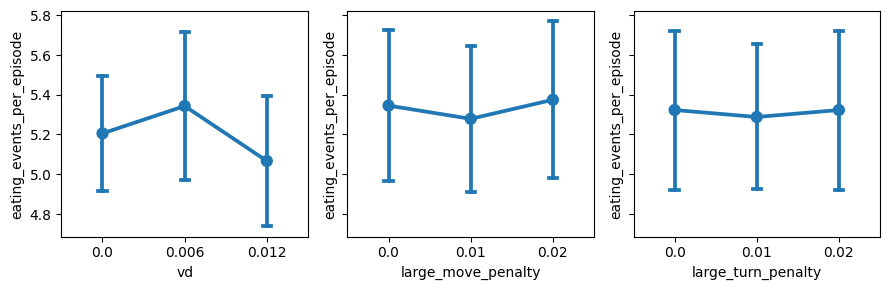

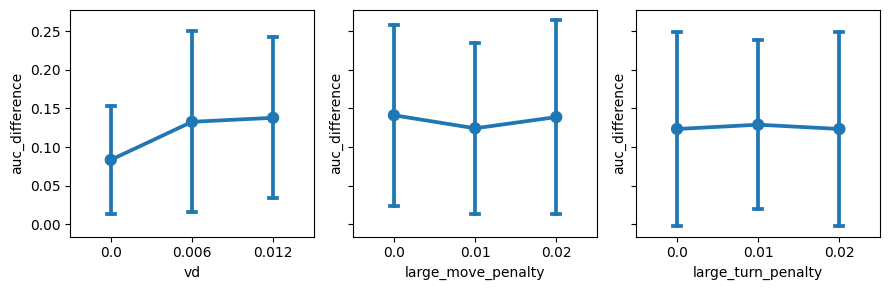

In [ ]:
control = {"vd": 0.006, "large_move_penalty": 0.01, "large_turn_penalty": 0.01}

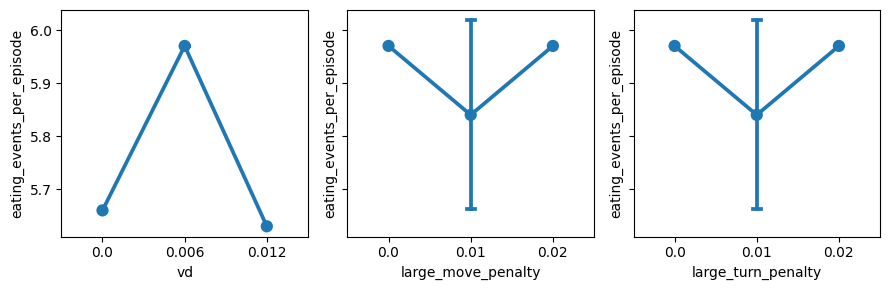

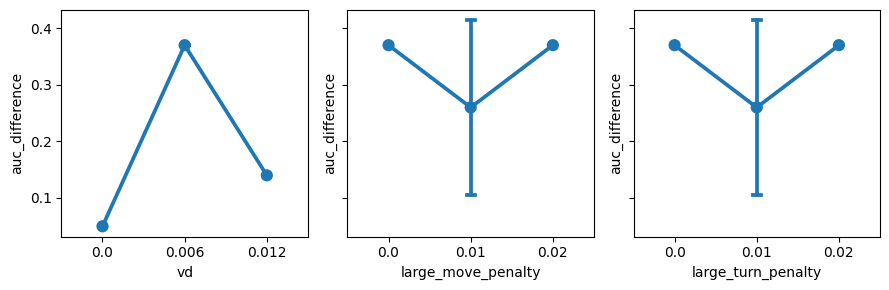

In [11]:
# Only best run per setting
best_runs = df_runs.loc[df_runs.groupby(sweep_dimensions)['eating_events_per_episode'].idxmax()]
for metric in metrics:
    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
    for i, dim in enumerate(sweep_dimensions):
        sns.pointplot(
            data=best_runs, x=dim, y=metric, 
            errorbar="sd",
            ax=axes[i], capsize=0.1
        )
        # axes[i].set_title(f"Best Runs: {metric} vs {dim}")
    plt.tight_layout()
    plt.show()


In [ ]:
# for metric in metrics:
#     for fixed in sweep_dimensions:
#         sub_dims = [d for d in sweep_dimensions if d != fixed]
#         pivot = (
#             df_runs.groupby(sub_dims)[metric]
#             .mean().reset_index()
#             .pivot(index=sub_dims[0], columns=sub_dims[1], values=metric)
#         )
#         sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
#         plt.title(f"{metric}, averaged over {fixed}")
#         plt.show()

# sns.catplot(
#     data=df_runs,
#     x="vd", y="eating_events_per_episode",
#     hue="large_move_penalty",
#     col="large_turn_penalty",
#     kind="bar", ci="sd", col_wrap=3, height=3
# )
# plt.show()


In [ ]:
df_runs[ df_runs["run"] == 0 ].shape